In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("Stock_apple.csv")
df.head()

,Unnamed: 0,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,AAPL,2015-05-27 00:00:00+00:00,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
1,1,AAPL,2015-05-28 00:00:00+00:00,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2,2,AAPL,2015-05-29 00:00:00+00:00,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
3,3,AAPL,2015-06-01 00:00:00+00:00,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
4,4,AAPL,2015-06-02 00:00:00+00:00,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


In [3]:
df.columns = df.columns.str.strip()

In [4]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index()
df = df.asfreq('D')
ts = df['adjClose']
ts = ts.ffill()

In [5]:
ts = df['adjClose']
ts = ts.ffill().bfill()
ts = ts.dropna()
ts.head()

date
2015-05-27 00:00:00+00:00    121.682558
2015-05-28 00:00:00+00:00    121.438354
2015-05-29 00:00:00+00:00    120.056069
2015-05-30 00:00:00+00:00    120.056069
2015-05-31 00:00:00+00:00    120.056069
Freq: D, Name: adjClose, dtype: float64

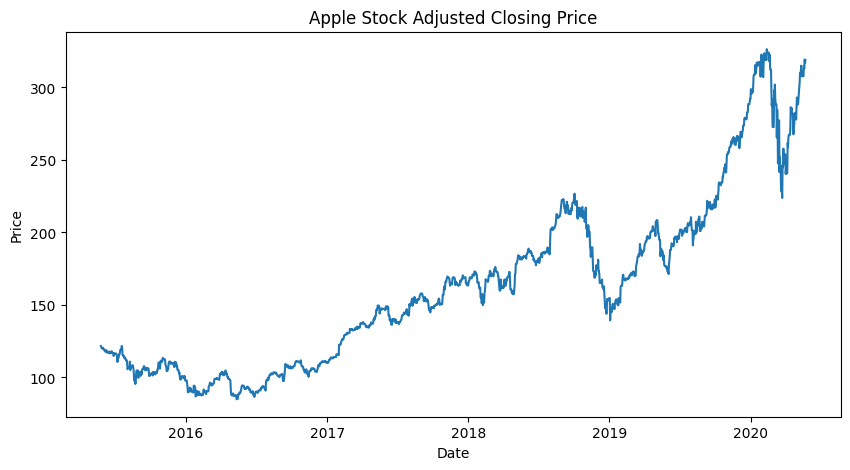

In [6]:
plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Apple Stock Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

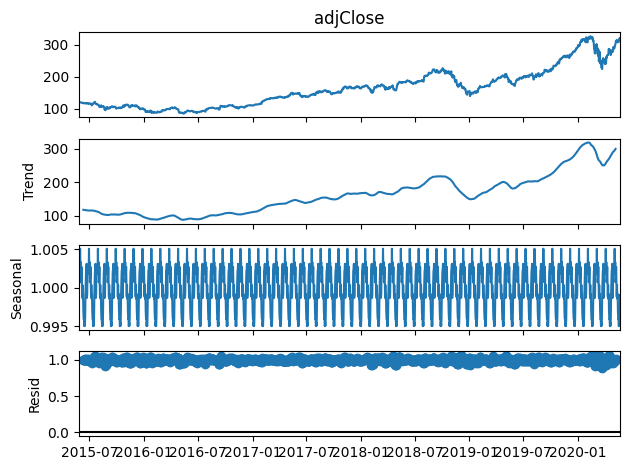

In [7]:
ts = ts.ffill().bfill()
decomposition = seasonal_decompose(ts, model='multiplicative', period=30)
decomposition.plot()
plt.show()

In [8]:
result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] <= 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")

ADF Statistic: 0.0952361923225161
p-value: 0.9657343377648989
Series is NOT Stationary


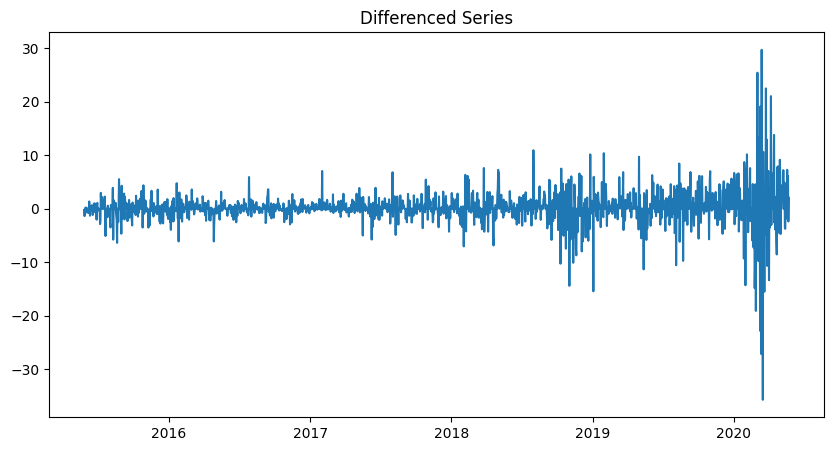

In [9]:
ts_diff = ts.diff().dropna()
plt.figure(figsize=(10,5))
plt.plot(ts_diff)
plt.title("Differenced Series")
plt.show()

In [10]:
train = ts[:-30]
test = ts[-30:]

In [11]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

In [12]:
forecast = model_fit.forecast(steps=30)

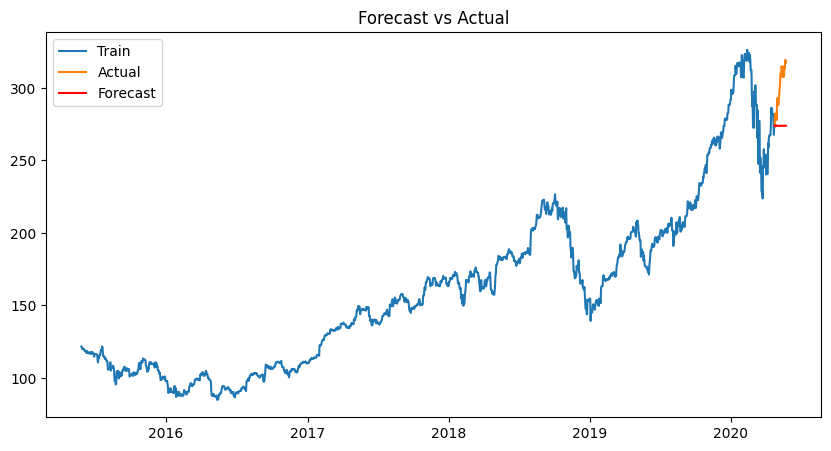

In [13]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [14]:
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 29.338036581711798
MAE: 26.027371439307277
